<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

# **Analysing football**
We have a dataset of football matches played by countries between 1872 and 2021. The dataset columns details are :

1. **date** : date of the match
2. **home_team** : Name of the home team
3. **away_team** : Name of the away team
4. **home_score** : goals scored by home team
5. **away_score** : goals scored by away team
6. **tournament** : type of match ( can be friendly, world cup qualifiers, intercontinental cup etc, out of 112 different types)
7. **city** : City where the match was played
8. **country** : Country where the match was played
9. **neutral** : Boolean that answers - was the venue a neutral venue?

<img src = "https://media.giphy.com/media/dKdtyye7l5f44/giphy.gif?cid=ecf05e47a4q297g5pwts4ju603f50tkbnzbeillnthaaj46t&rid=giphy.gif&ct=g"
style="margin-left:180px">
 
We will be doing the following with the dataset
## **Part 1**
- Take a look at the data and statistics
- Take a sample and compare statistics

## **Part 2**
- Calculate probability of scoring a goal any minute
- Calculate probability of win/loss/draw for Argentina vs Brazil

## **Part 3**
### **Part 3.1**
- Assuming scoring a goal at any minute as a bernoulli trial and running simulation
- Running simulations for a binomial experiment : total number of goals scored in a match

### **Part 3.2**
- Taking a look at the average waiting time inbetween 2 goals
- Fine tuning to get closer to continuous random variable

## **Part 4**
- Running a simulation, which takes team names as input and predicts the score line

In [48]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from scipy.special import factorial
from scipy import stats
%matplotlib inline

In [49]:
# Reading dataset and taking a look at it
data = pd.read_csv('results.csv')

<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

# Part 1 : Sampling and it's effect on statistics
We will take a sample of data i.e matches played after the year 1999 and compare the sample statistics to the complete dataset statistics


In [50]:
# Dataset sanity check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41640 entries, 0 to 41639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        41640 non-null  object
 1   home_team   41640 non-null  object
 2   away_team   41640 non-null  object
 3   home_score  41640 non-null  int64 
 4   away_score  41640 non-null  int64 
 5   tournament  41640 non-null  object
 6   city        41640 non-null  object
 7   country     41640 non-null  object
 8   neutral     41640 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 2.6+ MB


In [51]:
# Taking a look at few initial entries
data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

**Taking a look at the complete dataset statistics**

In [52]:
# Taking a look at the stats of the data set
data.describe()

,home_score,away_score
count,41640.000000,41640.000000
mean,1.744813,1.187680
std,1.753365,1.404828
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

**Taking a sample from the dataset i.e matches played after the year 1999, and calculating their statistics**

In [53]:
# Taking a look at a sample drawn from the data
data_sample = data[data['date'].apply(lambda x : int(str.split(x,'-')[0]))>=2000]
data_sample.describe()

,home_score,away_score
count,19192.000000,19192.000000
mean,1.639016,1.105096
std,1.721218,1.355228
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

As you can see the statistics (mean and std) changed quite a lot considering the size of the dataset. Hence sampling is a very crucial part of collecting data and if not done in the right manner can lead to incorrect results. 

<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

# Part 2 : Calculating Probability
We will calculate the average `home_score` and average `away_score`, and based on that will calculate the probability of home team scoring a goal any minute as well as probability of away team scoring a goal any minute.

Then we will consider a particular matchup - Argentina vs Brazil and calculate the probability of Argentina winning, losing and drawing.

In [54]:
# Calculate average home_score and away_score

avg_home = data['home_score'].mean()
avg_away = data['away_score'].mean()

print(avg_home,avg_away)

1.7448126801152737 1.1876801152737753


In [55]:
# Calculate probability of scoring a goal any minute

p_home = avg_home/90
p_away = avg_away/90

print('Probability of home team scoring any minute is: ',int(p_home*1000)/1000)
print('Probability of away team scoring any minute is: ',int(p_away*1000)/1000)

Probability of home team scoring any minute is:  0.019
Probability of away team scoring any minute is:  0.013


In [56]:
# Consider argentina vs brazil
prob_data = data[(data['home_team'] == 'Argentina') & (data['away_team'] == 'Brazil')]

total = len(prob_data)
win = len(prob_data[prob_data['home_score'] > prob_data['away_score']])
draw = len(prob_data[prob_data['home_score'] == prob_data['away_score']])
lose = len(prob_data[prob_data['home_score'] < prob_data['away_score']])

p_win = win/total
p_lose = lose/total
p_draw = draw/total

print("Probability of Argentina win: ",int(p_win*100)/100)
print("Probability of Argentina loss: ",int(p_lose*100)/100)
print("Probability of draw: ",int(p_draw*100)/100)

Probability of Argentina win:  0.46
Probability of Argentina loss:  0.25
Probability of draw:  0.27


<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

# Part 3
## 3.1 Bernoulli Trial and Binomial

We will consider the experiment : Goal scored at any given minute. We make the following assumptions to consider it a bernoulli trial :

1. There are only 2 outcomes(goal or no goal)
2. The probability of scoring a goal any minute is independent of any other minute (assumption made only for the sake of simplicity)

We run simulations to see at what times(minutes) in the match are goals scored

We will then extend this to a binomial experiment by considering total number of goals scored in a match. We then plot a histogram for the frequency of number of goals in a match.

## Bernoulli Experiment

In [57]:
# Preprocessing date to only have the year of the match
data['date']=data['date'].apply(lambda x : int(str.split(x,'-')[0]))

# Adding a new column which has total goals
data['total_goals']=data['home_score']+data['away_score']

# Getting avg of goals in matches played after year 2000
rec_data=data.loc[(data['date']>=2000)]
rec_data.iloc[[rec_data.total_goals.argmax()]]
avg_goals = rec_data.total_goals.mean()
print(avg_goals)

2.744112130054189


<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

**Running 90 bernoulli trials and plotting the count for success(goals) and failure(no-goals)**

Text(0.5, 1.0, 'Number of goals and No-goals')

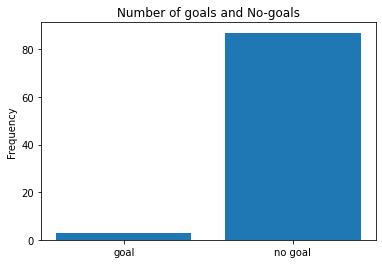

In [58]:
# Running the experiment for 90 times and plotting counts for success/failure
prob_goal = avg_goals/90
np.random.seed(42)

count = 0
for i in range(90):
  goals = np.random.choice([0,1],size=1,
                            replace=True,
                            p=[1-prob_goal,prob_goal])
  if goals == 1:
    count = count+1

plt.bar(['goal','no goal'],[count,90-count])
plt.ylabel('Frequency')
plt.title('Number of goals and No-goals')

<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

**Next we have 10 matches played (i.e run the 90-minute experiment 10 times) and observe the times at which goals are scored**

In [59]:
# Running the simulation for a match(90 min) for 10 times
# Observing the times when goals are scored

prob_goal = avg_goals/90
np.random.seed(42)

for i in range(10):
  goals = np.random.choice([0,1],size=90,
                            replace=True,
                            p=[1-prob_goal,prob_goal])
  success_times = np.where(goals==1)[0]
  print(success_times)

[11 50 69]
[49 64]
[46 81]
[35]
[30 81 86]
[21 25 48 49 68 72 81 82]
[41]
[31 45 75]
[]
[ 0 37]



## Binomial experiment

<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

**We run the experiment for one match and observe the `total_goals` scored**

In [60]:
# Taking a look at total goals in a match as predicted by random.choice
prob_goal = avg_goals/90
np.random.seed(42)
goals = np.random.choice([0,1],size=90,
                          replace=True,
                          p=[1-prob_goal,prob_goal])
total_goals = np.sum(goals)
print(total_goals)

3


<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

**Next we run the 90-minute experiment for 10,000 times and collect the number of goals scored in each match. We then plot it**

In [61]:
# Simulating total goals for 10000 matches to get the actual distribution
tot_goals = []
prob_goal=(2.74/90)
for i in range(10000):
    tot_goals.append(np.sum(np.random.choice([0, 1], size = 90, replace=True, 
                          p=[1-prob_goal, prob_goal])))

                  0
count  10000.000000
mean       2.767700
std        1.653121
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       11.000000


<Figure size 432x288 with 0 Axes>

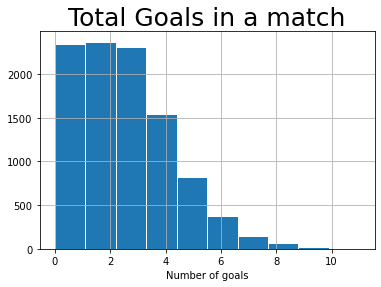

In [62]:
# Taking a look at the distribution
df= pd.DataFrame(tot_goals)
print(df.describe())
fig = plt.figure()
df.hist(bins=10,edgecolor='white')
plt.title('Total Goals in a match',fontsize=25)
plt.xlabel('Number of goals')
plt.grid(True)

<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

# Part 3
## 3.2
## Continuous RV

Let us say we turn on the TV at a random time and want to find out the waiting time for the next goal. We say that we are ready to watch another match, untill we see a goal(in case the first matches have no goals). We will calculate average waiting time in-between two goals in such a manner and observe the distribution over time. We will fine tune our plotting to make the plot finer and more continuous.

In [63]:
# Getting a set of waiting times between consecutive goals
# Using random.choice

prob_goal = avg_goals/90
np.random.seed(42)
goals = []
for i in range(10000):
    goals.extend(np.random.choice([0,1],size=90,
                          replace=True,
                          p=[1-prob_goal,prob_goal]))
success_times = np.where(np.array(goals)==1)[0]
waiting_times = np.diff(success_times)

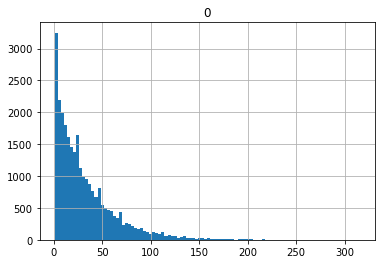

In [64]:
# Function to plot histogram
def plot_hist_waiting_time(x):
    df = pd.DataFrame(x)
    df.hist(bins=100)
# Taking a look at the distribution of waiting times
plot_hist_waiting_time(waiting_times)

In [65]:
#Simulating avg time for 1000 times you turn on the TV to get the actual average time
avg = []
prob_goal=(2.74/90)
for i in range(1000):
    avg_temp = []
    for i in range(1000):
        avg_temp.extend(np.diff(np.where(np.random.choice([0, 1], size = 90, replace=True, 
                          p=[1-prob_goal, prob_goal]) == 1)[0]))
    avg.append(np.mean(avg_temp))

<Figure size 432x288 with 0 Axes>

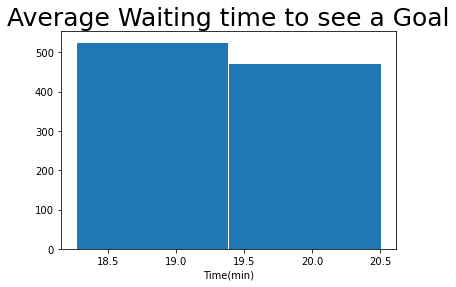

In [66]:
# Taking a look at distribution of average waiting times
df= pd.DataFrame(avg)
fig = plt.figure()
df.hist(bins=2,edgecolor='white')
plt.title('Average Waiting time to see a Goal',fontsize=25)
plt.xlabel('Time(min)')
plt.grid(False)
plt.show()

<Figure size 432x288 with 0 Axes>

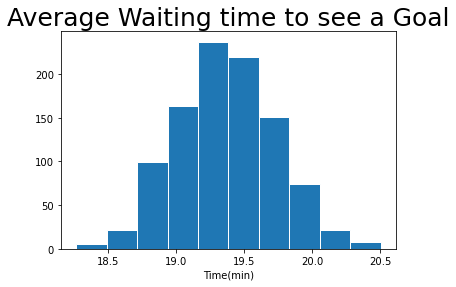

In [67]:
# Taking a look at distribution of average waiting times
df= pd.DataFrame(avg)
fig = plt.figure()
df.hist(edgecolor='white')
plt.title('Average Waiting time to see a Goal',fontsize=25)
plt.xlabel('Time(min)')
plt.grid(False)
plt.show()

<Figure size 432x288 with 0 Axes>

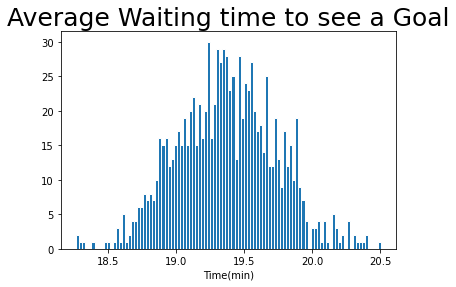

In [68]:
# Taking a look at distribution of average waiting times
df= pd.DataFrame(avg)
fig = plt.figure()
df.hist(bins=100,edgecolor='white')
plt.title('Average Waiting time to see a Goal',fontsize=25)
plt.xlabel('Time(min)')
plt.grid(False)
plt.show()

<div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA">

# Part 4
Predicting the scoreline of a match between 2 teams taken as inputs.
We will declare some helper functions first, the purpose of each is as follows:

1. p_lessorequal : Cumulates probability for goals less than or equal to the input.
2. p_greaterorequal : Cumulates probability for goals greater than or equal to the input.
3. get_goals : Takes a number and the probability distribution for number of goals as input and based on where the input number lies, generates the number of get_goals.
4. get_prob : Takes the mean goals as input and generates the binomial distribution like we generated earlier.

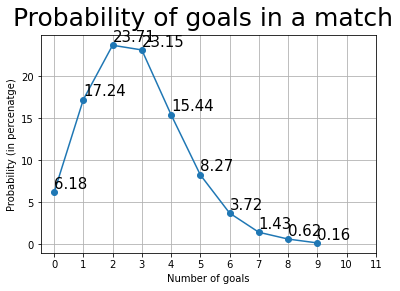

In [69]:
# Calculating probability of each number of goals scored in a match and plotting it
# We are using the binomial experiment results for determining probabilities
k=[]
p_k=[]
for i in range(10):
    p_k.append(tot_goals.count(i)/100)
    k.append(i)

fig = plt.figure()
plt.plot(k,p_k,'o-')
plt.xticks(range(12))
fig.suptitle('Probability of goals in a match',fontsize=25)
plt.xlabel('Number of goals')
plt.ylabel('Probability (in percenatge)')
for x,y in zip(k,p_k):

    label = "{:.2f}".format(y)

    plt.annotate(label, # this is the text
                 (x,y), # this is the point to label
                 textcoords="offset pixels", # how to position the text
                 xytext=(0,4), # distance from text to points (x,y)
                 ha='left',fontsize=15)
plt.grid(True)

In [70]:
# Functions for cumulative probabilities
def p_lessorequal(n_goals,prob,tot_goals,quiet=True):
    count=0
    for i in range(n_goals+1):
      count = count + tot_goals.count(i)
    p=count/len(tot_goals)
    if quiet:
        return p
    else:
        print(f'{prob} goals per game.Probability of {n_goals} or fewer goals in 1 game: {100*p:.2f}%.')
    
def p_greaterorequal(n_goals,prob,tot_goals,quiet=True):
    p = 1 - p_lessorequal(n_goals,prob,tot_goals)
    if quiet:
        return p
    else:
        print(f'Probability of more than {n_goals} goals in 1 game: {100*p:.2f}%.')
        


In [71]:
#probability of scoring more goals than a particular no.
for i in range(1,10):
    p_greaterorequal(i,2.74,tot_goals,False)

Probability of more than 1 goals in 1 game: 76.58%.
Probability of more than 2 goals in 1 game: 52.87%.
Probability of more than 3 goals in 1 game: 29.72%.
Probability of more than 4 goals in 1 game: 14.28%.
Probability of more than 5 goals in 1 game: 6.01%.
Probability of more than 6 goals in 1 game: 2.29%.
Probability of more than 7 goals in 1 game: 0.86%.
Probability of more than 8 goals in 1 game: 0.24%.
Probability of more than 9 goals in 1 game: 0.08%.


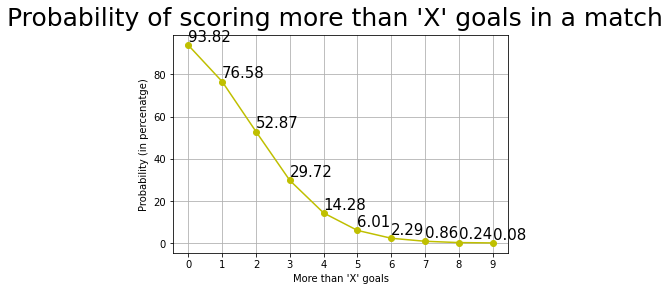

In [72]:
# Plotting cumulative probability
prob=[]
for i in range(10):
    p = p_greaterorequal(i,2.74,tot_goals,True)
    prob.append(p*100)
fig = plt.figure()
plt.plot(k,prob,'o-y')
plt.xticks(range(10))
fig.suptitle("Probability of scoring more than 'X' goals in a match",fontsize=25)
plt.xlabel("More than 'X' goals")
plt.ylabel('Probability (in percenatge)')
for x,y in zip(k,prob):

    label = "{:.2f}".format(y)

    plt.annotate(label, # this is the text
                 (x,y), # this is the point to label
                 textcoords="offset pixels", # how to position the text
                 xytext=(0,4), # distance from text to points (x,y)
                 ha='left',fontsize=15)
plt.grid(True)

In [73]:
# helper function to get goal prediction based on probability ranges
def get_goals(num,prob):
  if num<=prob[0] and num > prob[1]:
    goals=1
  elif num<=prob[1] and num > prob[2]:
    goals=2
  elif num<=prob[2] and num > prob[3]:
    goals=3
  elif num<=prob[3] and num > prob[4]:
    goals=4
  elif num<=prob[4] and num > prob[5]:
    goals=5
  elif num<=prob[5] and num > prob[6]:
    goals=6
  elif num<=prob[6] and num > prob[7]:
    goals=7
  elif num<=prob[7] and num > prob[8]:
    goals=8
  elif num<=prob[8]:
    goals=9
  else:
    goals=0
  return goals

In [74]:
# helper function to generate binomial distribution
def get_prob(mean):
  tot_goals = []
  prob_goal=(mean/90)
  for i in range(10000):
      tot_goals.append(np.sum(np.random.choice([0, 1], size = 90, replace=True, 
                            p=[1-prob_goal, prob_goal])))
      
  prob=[]
  for i in range(10):
      p = p_greaterorequal(i,2.74,tot_goals,True)
      prob.append(p)

  return prob      

## predicting scores by simulation

In [75]:
# Cleaning up the team names so that comparing inputs is easier
data['home_team'] = data['home_team'].apply(lambda x: (''.join(x.split())).lower())
data['away_team'] = data['away_team'].apply(lambda x: (''.join(x.split())).lower())

In [76]:
# Actual simulation function
def PredictScore():
    
    home_team = input("Enter Home Team: ")
    ht = (''.join(home_team.split())).lower()
    away_team = input("Enter Away Team: ")
    at = (''.join(away_team.split())).lower()
    
    # Checking if we have enough data
    if len(data[(data.home_team ==ht) & (data.away_team ==at)]) > 20:
        
        #Pulling out relevant dataset entries and calculating avg home and away score
        avg_home_score = data[(data.home_team ==ht) & (data.away_team ==at)].home_score.mean()
        avg_away_score = data[(data.home_team ==ht) & (data.away_team ==at)].away_score.mean()
        goals_away=[]
        goals_home=[]

        # Getting the binomial distribution generated, so that we have probability ranges
        prob_home = get_prob(avg_home_score)
        prob_away = get_prob(avg_away_score)
        print('Running Simulation')
        for i in range(10000):

          #Getting goal predictions for 10000 simulations for away and home
          random_flip = np.random.random()
          goals_away.append(get_goals(random_flip,prob_away))
          random_flip = np.random.random()
          goals_home.append(get_goals(random_flip,prob_home))

        # Taking the mode of a sample of the dataset
        home_goal = int(stats.mode(np.random.choice(goals_home,100))[0])
        away_goal = int(stats.mode(np.random.choice(goals_away,100))[0])
        
    else:
        # In case of not enough data, consider the goals conceded along with goals scored by opposition
        # To get better average value
        avg_home_goal_conceded = data[(data.home_team ==ht)].away_score.mean()
        avg_away_goal_scored   = data[(data.away_team ==at)].away_score.mean()
        avg_away_score = 1/2*(avg_home_goal_conceded+avg_away_goal_scored)
        
        avg_away_goal_conceded = data[(data.home_team ==at)].home_score.mean()
        avg_home_goal_scored   = data[(data.away_team ==ht)].home_score.mean()
        avg_home_score = 1/2*(avg_away_goal_conceded+avg_home_goal_scored)
        goals_away=[]
        goals_home=[]
        prob_home = get_prob(avg_home_score)
        prob_away = get_prob(avg_away_score)
        print('running simulation')
        for i in range(10000):
          random_flip = np.random.random()
          goals_away.append(get_goals(random_flip,prob_away))
          random_flip = np.random.random()
          goals_home.append(get_goals(random_flip,prob_home))

        home_goal = int(stats.mode(np.random.choice(goals_home,1))[0])
        away_goal = int(stats.mode(np.random.choice(goals_away,1))[0])
    
    print(f'They have played {len(data[(data.home_team ==ht) & (data.away_team ==at)])} matches')
    print(f'The scoreline is {home_team} {home_goal}:{away_goal} {away_team}')
    #return goals_away,goals_home,home_goal,away_goal

In [79]:
# Provide inputs and run this cell to run simulation
PredictScore()

running simulation
They have played 14 matches
The scoreline is england 2:1 brazil


In [78]:
#Search in google: "last match between {home_team vs {away_team}}"